In [1]:
import numpy as np
from numba import njit, prange

@njit(parallel=True)  
def sample_lba(n_samples, A, b, v, s, t0):
    """
    Samples from the Linear Ballistic Accumulator (LBA).
    Robust against 'inf' errors and negative choice indices.
    """
    
    n_choices = len(v)
    rts = np.empty(n_samples, dtype=np.float64)
    choices = np.empty(n_samples, dtype=np.int32)
    
    threshold = A + b

    for i in prange(n_samples):
        
        # Loop until a valid race is generated (at least one positive drift)
        while True:
            min_t = 1e308      # Initialize with a huge number (simulating infinity)
            winner = -1        # Initialize with an invalid choice index
            
            for c in range(n_choices):
                # 1. Sample Start Point
                start_point = np.random.random() * A
                
                # 2. Sample Drift Rate
                drift_rate = np.random.normal(v[c], s)
                
                # 3. Calculate Time
                if drift_rate > 0:
                    # Only calculate time if moving towards threshold
                    t_accum = (threshold - start_point) / drift_rate
                    
                    if t_accum < min_t:
                        min_t = t_accum
                        winner = c
            
            # 4. Valid Trial Check
            # We only record and break if we found a winner (winner != -1)
            if winner != -1:
                rts[i] = t0 + min_t
                choices[i] = winner
                break 

    return rts, choices

In [25]:
import numpy as np

# --- Parameters ---
N_TRIALS = 10000
A_START = 1.0       # Max start point
B_GAP = 0.5         # Gap (so Absolute Threshold = 1.0 + 0.5 = 1.0)
T0 = 0.2
V_RATES = np.array([2.5, 1.5, 1.5]) # 3 Choices
S_RATE = 1.0        # Shared drift noise

# --- Simulation ---
rts, choices = sample_lba(N_TRIALS, A_START, B_GAP, V_RATES, S_RATE, T0)

# --- Check Results ---
print(f"Mean RT: {np.mean(rts):.3f}")
print(f"Choice Probabilities: {np.bincount(choices) / N_TRIALS}")

Mean RT: 0.560
Choice Probabilities: [0.5772 0.212  0.2108]


<Axes: ylabel='Count'>

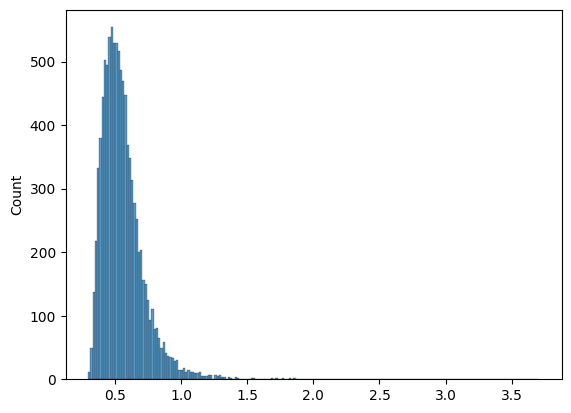

In [26]:
import seaborn as sns
sns.histplot(rts)